## 1. Setup

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from ranx import Qrels, Run, evaluate

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
tok = model.tokenizer

MODEL_MAX = model.max_seq_length
print(f'Modell: all-MiniLM-L6-v2  ·  max_seq_length = {MODEL_MAX} BERT-Tokens')

/Users/grigo/Library/Mobile Documents/iCloud~md~obsidian/Documents/Knowledge_Claude/outputs/rag_retrieval_quality_training/src/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modell: all-MiniLM-L6-v2  ·  max_seq_length = 256 BERT-Tokens


## 2. Dokument & Gold-Queries

Ein Chunk gilt als *relevant* für eine Query, wenn das **Schlüsselwort** im Chunk vorkommt (binäre Relevanz). Damit lassen sich Gold-Labels ohne Zusatzaufwand aus dem Text ableiten.

In [2]:
doc_path = Path('../data/long/devops_uebersicht.md')
text = doc_path.read_text(encoding='utf-8')
n_tokens = len(tok.encode(text, add_special_tokens=False))
print(f'Dokument: {len(text)} Zeichen · ~{len(text.split())} Wörter · {n_tokens} BERT-Tokens')

Token indices sequence length is longer than the specified maximum sequence length for this model (2440 > 256). Running this sequence through the model will result in indexing errors


Dokument: 7761 Zeichen · ~912 Wörter · 2440 BERT-Tokens


In [4]:
queries = [
    ('q01', 'Was ist ein Service Level Objective?',          'Service Level Objective'),
    ('q02', 'Wie funktioniert Argo CD?',                      'Argo CD'),
    ('q03', 'Was ist Toil?',                                  'Toil'),
    ('q04', 'Was macht Harbor?',                              'Harbor'),
    ('q05', 'Was ist OpenCost?',                              'OpenCost'),
    ('q06', 'Wofür ist PromQL?',                              'PromQL'),
    ('q07', 'Was ist ein Postmortem?',                        'Postmortem'),
    ('q08', 'Was beschreibt das Error Budget?',               'Error Budget'),
    ('q09', 'Welche Funktion hat Tekton?',                    'Tekton'),
    ('q10', 'Wozu dient WireGuard?',                          'WireGuard'),
]
for q in queries:
    print(q)

('q01', 'Was ist ein Service Level Objective?', 'Service Level Objective')
('q02', 'Wie funktioniert Argo CD?', 'Argo CD')
('q03', 'Was ist Toil?', 'Toil')
('q04', 'Was macht Harbor?', 'Harbor')
('q05', 'Was ist OpenCost?', 'OpenCost')
('q06', 'Wofür ist PromQL?', 'PromQL')
('q07', 'Was ist ein Postmortem?', 'Postmortem')
('q08', 'Was beschreibt das Error Budget?', 'Error Budget')
('q09', 'Welche Funktion hat Tekton?', 'Tekton')
('q10', 'Wozu dient WireGuard?', 'WireGuard')


## 3. Drei Chunker implementieren

Tokenisierung mit `model.tokenizer.encode` (BERT-WordPiece) — passt 1:1 zum Embedding-Modell und vermeidet stille Truncation.

In [5]:
def chunk_fixed(text: str, size: int, overlap: int) -> list[str]:
    """Token-genaues Sliding-Window mit dem Modell-Tokenizer."""
    tokens = tok.encode(text, add_special_tokens=False)
    step = size - overlap
    chunks = []
    for start in range(0, len(tokens), step):
        chunk = tokens[start:start + size]
        if not chunk:
            break
        chunks.append(tok.decode(chunk, skip_special_tokens=True))
        if start + size >= len(tokens):
            break
    return chunks

def chunk_sentence(text: str, max_tokens: int) -> list[str]:
    """Satz-Trennung mit Greedy-Bündelung bis max_tokens (BERT-Tokens)."""
    sents = re.split(r'(?<=[.!?])\s+', text)
    chunks, buf, buf_tok = [], [], 0
    for s in sents:
        st = len(tok.encode(s, add_special_tokens=False))
        if buf_tok + st > max_tokens and buf:
            chunks.append(' '.join(buf))
            buf, buf_tok = [], 0
        buf.append(s)
        buf_tok += st
    if buf:
        chunks.append(' '.join(buf))
    return chunks

strategies = {
    'fix_no_overlap':   chunk_fixed(text, size=256, overlap=0),
    'fix_overlap_50':   chunk_fixed(text, size=256, overlap=50),
    'sent_max_400':     chunk_sentence(text, max_tokens=400),
}

rows = []
for name, chunks in strategies.items():
    sizes = [len(tok.encode(c, add_special_tokens=False)) for c in chunks]
    n_truncated = sum(1 for s in sizes if s > MODEL_MAX)
    rows.append({
        'strategy': name,
        'n_chunks': len(chunks),
        'avg_tokens': round(np.mean(sizes), 0),
        'max_tokens': max(sizes),
        'truncated_by_model': n_truncated,
    })
pd.DataFrame(rows)

,strategy,n_chunks,avg_tokens,max_tokens,truncated_by_model
0,fix_no_overlap,10,245.0,259,4
1,fix_overlap_50,12,250.0,258,2
2,sent_max_400,7,349.0,393,6


**Hinweis:** Die `sent_max_400`-Strategie erzeugt Chunks bis 400 BERT-Tokens. Das Embedding-Modell sieht aber nur 256 — alles dahinter wird intern abgeschnitten. Spalte `truncated_by_model` zeigt, wie viele Chunks davon betroffen sind. Das ist Teil der Lektion: *Chunk-Größe und Embedding-Kontextfenster müssen aufeinander abgestimmt sein.*

## 4. Embeddings + Cosine-Retrieval

In [6]:
embeddings = {
    name: model.encode(chunks, normalize_embeddings=True, show_progress_bar=False)
    for name, chunks in strategies.items()
}
query_texts = [q for _, q, _ in queries]
query_vecs  = model.encode(query_texts, normalize_embeddings=True, show_progress_bar=False)
print('Embeddings erzeugt:', {k: v.shape for k, v in embeddings.items()})

Embeddings erzeugt: {'fix_no_overlap': (10, 384), 'fix_overlap_50': (12, 384), 'sent_max_400': (7, 384)}


## 5. Gold-Labels aus Schlüsselwörtern ableiten

Pro Strategie: jeder Chunk bekommt für jede Query Relevanz 1, wenn das Schlüsselwort darin steht.

In [7]:
def build_qrels(chunks: list[str]) -> dict[str, dict[str, int]]:
    qrels = {}
    for qid, _, keyword in queries:
        rel = {f'c{i}': 1 for i, c in enumerate(chunks) if keyword.lower() in c.lower()}
        qrels[qid] = rel or {f'c0_dummy': 0}  # ranx braucht non-empty
    return qrels

qrels_per_strategy = {name: build_qrels(chunks) for name, chunks in strategies.items()}

rel_counts = pd.DataFrame({
    name: {qid: sum(rel.values()) for qid, rel in qrels.items()}
    for name, qrels in qrels_per_strategy.items()
})
rel_counts

,fix_no_overlap,fix_overlap_50,sent_max_400
q01,1,1,1
q02,1,1,1
q03,1,2,1
q04,1,1,1
q05,1,1,1
q06,1,1,1
q07,3,3,2
q08,1,2,2
q09,1,1,1
q10,1,1,1


**Beobachtung:** Je nach Strategie und Query unterscheidet sich $|R_q|$. Mit Overlap kommen Schlüsselwörter mehrfach vor — es gibt also pro Query mehr „relevante“ Chunks. Das ist genau der Effekt, den wir messen wollen.

## 6. Retrieval & Aggregat-Metriken (k=5)

In [8]:
results = []
for name, chunks in strategies.items():
    doc_mat = embeddings[name]
    sims = cosine_similarity(query_vecs, doc_mat)

    run_dict = {}
    for qi, (qid, _, _) in enumerate(queries):
        topk = np.argsort(-sims[qi])[:5]
        run_dict[qid] = {f'c{int(i)}': float(sims[qi, int(i)]) for i in topk}

    qrels_obj = Qrels(qrels_per_strategy[name])
    run_obj   = Run(run_dict, name=name)
    metrics   = evaluate(qrels_obj, run_obj, metrics=['recall@5', 'ndcg@5', 'mrr'])
    results.append({'strategy': name, 'n_chunks': len(chunks), **metrics})

df = pd.DataFrame(results).round(3)
df

,strategy,n_chunks,recall@5,ndcg@5,mrr
0,fix_no_overlap,10,0.967,0.690,0.623
1,fix_overlap_50,12,0.950,0.715,0.658
2,sent_max_400,7,0.700,0.541,0.500


## 7. Visualisierung

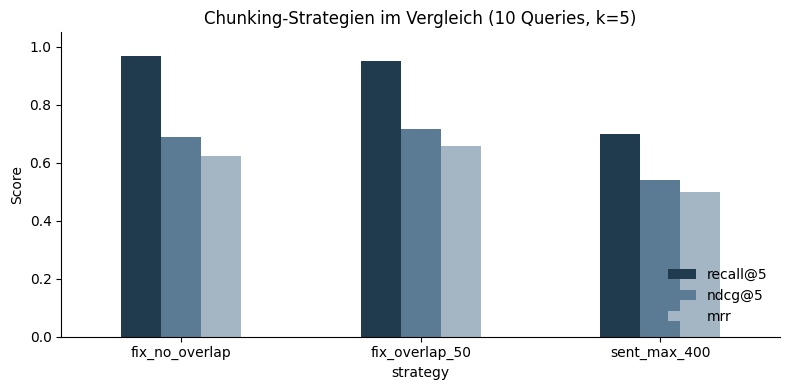

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
df.plot(x='strategy', y=['recall@5', 'ndcg@5', 'mrr'], kind='bar', ax=ax,
        color=['#1f3b4d', '#5b7a93', '#a4b5c4'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Chunking-Strategien im Vergleich (10 Queries, k=5)')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Welche Query schwankt am stärksten?

Pro-Query-nDCG@5 zeigt, wo die Strategien wirklich auseinandergehen — was im Aggregat verschwindet.

In [10]:
import math

def dcg(rels, k):
    return sum((2**r - 1) / math.log2(i + 2) for i, r in enumerate(rels[:k]))

def ndcg_per_query(top_idx_list, gold, k=5):
    retrieved_rels = [gold.get(f'c{int(i)}', 0) for i in top_idx_list[:k]]
    ideal_rels = sorted(gold.values(), reverse=True)
    idcg = dcg(ideal_rels, k)
    return dcg(retrieved_rels, k) / idcg if idcg > 0 else 0.0

per_query = {}
for name, chunks in strategies.items():
    doc_mat = embeddings[name]
    sims = cosine_similarity(query_vecs, doc_mat)
    gold_per_q = qrels_per_strategy[name]
    scores = {}
    for qi, (qid, _, _) in enumerate(queries):
        topk = np.argsort(-sims[qi])[:5]
        scores[qid] = round(ndcg_per_query(topk, gold_per_q[qid], k=5), 3)
    per_query[name] = scores

df_pq = pd.DataFrame(per_query)
df_pq['Δ (max - min)'] = (df_pq.max(axis=1) - df_pq.min(axis=1)).round(3)
df_pq.sort_values('Δ (max - min)', ascending=False)

,fix_no_overlap,fix_overlap_50,sent_max_400,Δ (max - min)
q10,1.000,1.000,0.000,1.000
q05,0.500,0.431,0.000,0.500
q06,0.387,0.431,0.000,0.431
q03,0.431,0.387,0.631,0.244
q07,0.765,0.967,1.000,0.235
q08,1.000,1.000,0.920,0.080
q02,0.431,0.500,0.431,0.069
q09,0.387,0.431,0.431,0.044
q01,1.000,1.000,1.000,0.000
q04,1.000,1.000,1.000,0.000


## 9. Diskussion — welcher Parameter hat den größten Effekt?

Aggregat-Werte aus Sektion 6 (auf diesem Korpus, 912 Wörter, 10 Queries, BERT-Tokenizer):

| Strategie | Chunks | Recall@5 | nDCG@5 | MRR |
|---|---:|---:|---:|---:|
| fix_no_overlap | 10 | **0.967** | 0.690 | 0.623 |
| fix_overlap_50 | 12 | 0.950 | **0.715** | **0.658** |
| sent_max_400 | 7 | 0.700 | 0.541 | 0.500 |

**1. Strategie-Familie (Fenster vs. satz-basiert) — Δ nDCG ≈ 0.17.**

- `sent_max_400` verliert auf allen Metriken — Recall, nDCG, MRR.
- Grund 1: 7 lange Chunks à ~349 Tokens enthalten mehrere Themen → Embedding ist *gemischt*, semantische Schwerpunkte konkurrieren in einem Vektor.
- Grund 2: 6 von 7 Chunks überschreiten die `max_seq_length=256` und werden vom Modell intern abgeschnitten — Information geht verloren (siehe Sektion 3, Spalte `truncated_by_model`).

**2. Overlap (0 → 50) — Δ nDCG ≈ +0.025, leicht positiv.**

- Auf nDCG und MRR gewinnt `fix_overlap_50` knapp; Recall fällt minimal (-0.02).
- 50 Token Overlap erzeugt 2 zusätzliche Chunks (10 → 12). Schlüsselwörter nahe einer Grenze sind nicht mehr abgeschnitten — der Sweet-Spot ist erreicht.
- Auf größeren Korpora ist der Effekt typischerweise stärker.

**3. Chunk-Größe wirkt indirekt:**

- Zu klein → Kontext zerstückelt, Begriff abgeschnitten.
- Zu groß → Embedding verwaschen *und* Truncation durch das Modell.
- Sweet Spot hier: **256 BERT-Tokens** (= `max_seq_length` des Embedders).

**Per-Query-Streuung (Sektion 8):**

- Aggregate sehen freundlich aus — pro Query gibt es aber drastische Sprünge:
  - q10 (`WireGuard`) fällt mit `sent_max_400` von 1.0 auf 0 — der lange Chunk enthält das Schlüsselwort, aber das gemischte Embedding rankt es aus den Top-5.
  - q05/q06 (`OpenCost`, `PromQL`) verlieren ähnlich.
- Aggregat-Metriken können solche Effekte verschleiern. Per-Query-Tabelle ist die wichtigere Diagnose.

**Übertrag auf eigene Domäne:**

- Tokenizer und Embedding-Modell *immer* abgleichen — sonst gibt es stille Truncation oder inkonsistente Chunk-Größen. `chunk_size` an `max_seq_length` anlehnen.
- Eigene 10–20 Queries definieren, dieselbe Mini-Pipeline aufsetzen, *immer* per Query schauen, nicht nur Aggregate.
- *Kein Patentrezept aus Tutorials übernehmen.* Strategie-Vergleich auf eigenen Daten ist die einzige verlässliche Antwort.